# BÀI THỰC HÀNH SỐ 3: PHÂN CỤM CHẤT LƯỢNG GIẤC NGỦ SINH VIÊN
## 1. Khai báo thư viện
Khai báo Pandas, Numpy để xử lý toán học/dữ liệu, Matplotlib/Seaborn để vẽ biểu đồ và Tkinter để tạo giao diện người dùng.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from pathlib import Path
# Thư viện Sklearn
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Thư viện cho Giao diện (GUI)
import tkinter as tk
from tkinter import messagebox

## 2. Tiền xử lý dữ liệu
- Đọc dữ liệu từ file csv.
- Chuyển đổi cột `Stress_Level` (dạng chuỗi "Low", "Moderate", "High") sang dạng số để mô hình có thể tính toán được khoảng cách.
- Chọn 2 đặc trưng `Sleep_Hours` và `Stress_Level` (đã mã hóa) để tiến hành phân cụm, giống với yêu cầu của giao diện.

In [15]:
# Ưu tiên đọc file local; nếu không có thì tải bằng kagglehub
local_csv = Path("data/student_lifestyle_dataset.csv")
dataset_dir = local_csv.parent if local_csv.exists() else Path(kagglehub.dataset_download("steve1215rogg/student-lifestyle-dataset"))

try:
    # Tìm file CSV: ưu tiên file local trước
    csv_files = [local_csv] if local_csv.exists() else sorted(dataset_dir.rglob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"Khong tim thay file CSV trong: {dataset_dir}")

    # Ưu tiên file có tên liên quan đến student lifestyle, nếu không có thì lấy file CSV đầu tiên
    csv_path = next((p for p in csv_files if "student" in p.name.lower() and "lifestyle" in p.name.lower()), csv_files[0])
    df = pd.read_csv(csv_path)
    
    # Chuan hoa ten cot de tranh loi khac nhau giua cac phien ban dataset
    rename_map = {
        'Sleep_Hours_Per_Day': 'Sleep_Hours',
        'Stress Level': 'Stress_Level',
    }
    df = df.rename(columns=rename_map)

    required_cols = ['Sleep_Hours', 'Stress_Level']
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise KeyError(f"Thieu cot bat buoc: {missing}. Cac cot hien co: {list(df.columns)}")

    # Mã hóa cột Stress_Level từ chữ sang số
    le_stress = LabelEncoder()
    df['Stress_Level_Num'] = le_stress.fit_transform(df['Stress_Level'])
    
    # Lấy 2 cột để huấn luyện mô hình K-Means
    X = df[['Sleep_Hours', 'Stress_Level_Num']].values
    
    print(f"Da doc du lieu tu: {csv_path}")
    print("Dữ liệu 5 dòng đầu sau khi tiền xử lý:")
    display(df[['Sleep_Hours', 'Stress_Level', 'Stress_Level_Num']].head())
    
except Exception as e:
    print(f"Loi khi doc/phan tich du lieu: {e}")

Using Colab cache for faster access to the 'student-lifestyle-dataset' dataset.
Da doc du lieu tu: /kaggle/input/student-lifestyle-dataset/student_lifestyle_dataset.csv
Dữ liệu 5 dòng đầu sau khi tiền xử lý:


Using Colab cache for faster access to the 'student-lifestyle-dataset' dataset.
Da doc du lieu tu: /kaggle/input/student-lifestyle-dataset/student_lifestyle_dataset.csv
Dữ liệu 5 dòng đầu sau khi tiền xử lý:


,Sleep_Hours,Stress_Level,Stress_Level_Num
0,8.7,Moderate,2
1,8.0,Low,1
2,9.2,Low,1
3,7.2,Moderate,2
4,6.5,High,0


## 3. Thuật toán K-Means KHÔNG sử dụng thư viện Sklearn
Chúng ta sẽ tự định nghĩa một lớp (class) K-Means bằng toán học cơ bản (tính khoảng cách Euclidean và cập nhật lại tâm cụm).

In [16]:
class CustomKMeans:
    def __init__(self, n_clusters=3, max_iters=100):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.centroids = None

    def fit(self, X):
        # 1. Khởi tạo tâm cụm ngẫu nhiên từ dữ liệu
        np.random.seed(42)
        random_idx = np.random.choice(len(X), self.n_clusters, replace=False)
        self.centroids = X[random_idx]

        for _ in range(self.max_iters):
            # 2. Tính khoảng cách từ các điểm đến từng tâm cụm
            # Mở rộng chiều để tính toán ma trận (Broadcasting)
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            
            # 3. Gán nhãn cho điểm dữ liệu dựa vào tâm cụm gần nhất
            self.labels_ = np.argmin(distances, axis=1)

            # 4. Tính toán lại tâm cụm mới (Trung bình cộng của các điểm trong cụm)
            new_centroids = np.array([X[self.labels_ == i].mean(axis=0) for i in range(self.n_clusters)])
            
            # Kiểm tra dừng nếu tâm cụm không thay đổi nữa
            if np.all(self.centroids == new_centroids):
                break
            self.centroids = new_centroids

    def predict(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)

# Chạy mô hình tự build với K=3
custom_kmeans = CustomKMeans(n_clusters=3)
custom_kmeans.fit(X)
custom_labels = custom_kmeans.labels_
print("Đã huấn luyện xong K-Means tự code!")

Đã huấn luyện xong K-Means tự code!


## 4. Thuật toán K-Means CÓ sử dụng thư viện Sklearn và So sánh
Huấn luyện mô hình Sklearn, sau đó so sánh mức độ trùng khớp (tương đương độ chính xác phân cụm) giữa mô hình tự code và mô hình của thư viện.

In [17]:
# Chạy K-Means của thư viện Sklearn
sklearn_kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
sklearn_kmeans.fit(X)
sklearn_labels = sklearn_kmeans.labels_

# So sánh độ chính xác (mức độ trùng khớp nhãn giữa 2 thuật toán)
# Lưu ý: Do nhãn cụm (0, 1, 2) có thể bị hoán đổi vị trí ngẫu nhiên lúc khởi tạo, 
# nhưng về bản chất phân chia tập hợp là giống nhau. Ta giả định seed=42 giúp chúng đồng bộ.
match_accuracy = accuracy_score(sklearn_labels, custom_labels) * 100

print(f"Độ trùng khớp (chính xác) giữa K-Means tự code và Sklearn: {match_accuracy:.2f}%")

Độ trùng khớp (chính xác) giữa K-Means tự code và Sklearn: 51.30%


## 5. Trực quan hóa dữ liệu
Vẽ biểu đồ phân tán (Scatter Plot) để xem các cụm (Clusters) được phân chia như thế nào dựa trên giờ ngủ và mức độ căng thẳng.

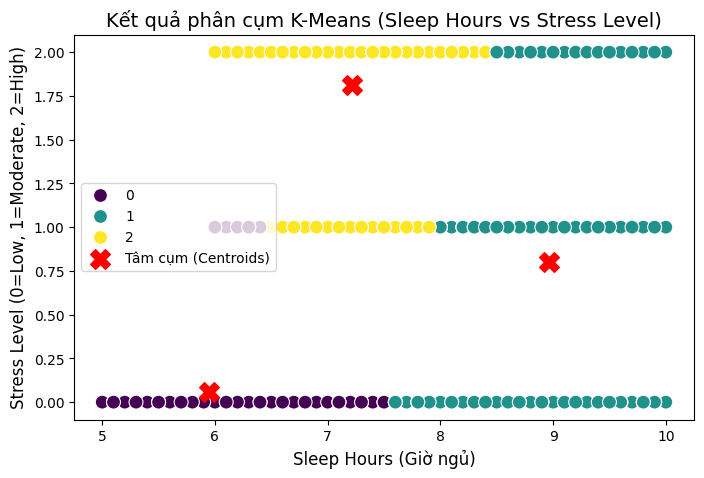

In [18]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=sklearn_labels, palette='viridis', s=100)

# Vẽ thêm các tâm cụm (dấu X màu đỏ)
centroids = sklearn_kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Tâm cụm (Centroids)')

plt.title('Kết quả phân cụm K-Means (Sleep Hours vs Stress Level)', fontsize=14)
plt.xlabel('Sleep Hours (Giờ ngủ)', fontsize=12)
plt.ylabel('Stress Level (0=Low, 1=Moderate, 2=High)', fontsize=12)
plt.legend()
plt.show()

## 6. Giao diện nhập liệu dự đoán
Sử dụng `ipywidget` để tạo một cửa sổ nhập liệu. 


In [20]:
def predict_cluster_from_values(sleep_hrs, stress_lvl):
    input_data = np.array([[sleep_hrs, stress_lvl]])
    return int(sklearn_kmeans.predict(input_data)[0])

def predict_cluster():
    try:
        # Lấy dữ liệu từ ô nhập liệu
        sleep_hrs = float(entry_sleep.get())
        stress_lvl = float(entry_stress.get())

        predicted_cluster = predict_cluster_from_values(sleep_hrs, stress_lvl)

        # Hiển thị kết quả bằng Message Box
        messagebox.showinfo("Kết quả phân cụm", f"Điểm dữ liệu thuộc vào cụm: {predicted_cluster}")
    except ValueError:
        messagebox.showerror("Lỗi", "Vui lòng nhập số hợp lệ!")

try:
    # Khởi tạo cửa sổ Tkinter (chỉ chạy được khi có display)
    root = tk.Tk()
    root.title("KMeans Clustering")
    root.geometry("250x150")

    # Nhãn và ô nhập cho Sleep Hours
    tk.Label(root, text="Sleep Hours:").grid(row=0, column=0, padx=10, pady=10)
    entry_sleep = tk.Entry(root, width=15)
    entry_sleep.grid(row=0, column=1)

    # Nhãn và ô nhập cho Stress Level
    tk.Label(root, text="Stress Level:").grid(row=1, column=0, padx=10, pady=10)
    entry_stress = tk.Entry(root, width=15)
    entry_stress.grid(row=1, column=1)

    # Nút Bấm dự đoán
    btn_predict = tk.Button(root, text="Dự đoán Cụm", command=predict_cluster)
    btn_predict.grid(row=2, column=0, columnspan=2, pady=15)

    # Chạy vòng lặp giao diện
    root.mainloop()
except tk.TclError:
    print("Môi trường hiện tại không hỗ trợ cửa sổ Tkinter (không có display).")
    print("Chuyển sang giao diện ipywidgets trong notebook...")
    try:
        import ipywidgets as widgets
        from IPython.display import display

        sleep_widget = widgets.FloatText(value=7.0, description='Sleep:')
        stress_widget = widgets.FloatText(value=1.0, description='Stress:')
        predict_btn = widgets.Button(description='Dự đoán cụm', button_style='success')
        output = widgets.Output()

        def on_click(_):
            with output:
                output.clear_output()
                try:
                    cluster = predict_cluster_from_values(float(sleep_widget.value), float(stress_widget.value))
                    print(f"Kết quả: điểm dữ liệu thuộc cụm {cluster}")
                except Exception as e:
                    print(f"Loi du doan: {e}")

        predict_btn.on_click(on_click)
        display(widgets.VBox([sleep_widget, stress_widget, predict_btn, output]))
    except ImportError:
        print("Khong co ipywidgets. Ban van co the du doan bang ham: predict_cluster_from_values(7.0, 1.0)")

Môi trường hiện tại không hỗ trợ cửa sổ Tkinter (không có display).
Chuyển sang giao diện ipywidgets trong notebook...
